In [23]:
# ======================
# Imports
# ======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [24]:
# ======================
# Load Dataset
# ======================
df = pd.read_csv("household_power_consumption.txt", sep=';', low_memory=False)

print("Original shape:", df.shape)

# Reduce size for faster processing
df = df.sample(n=50000, random_state=42)

print("Sampled shape:", df.shape)

Original shape: (2075259, 9)
Sampled shape: (50000, 9)


In [25]:
# ======================
# Data Cleaning
# ======================
df.replace('?', pd.NA, inplace=True)
df = df.dropna()

cols = ['Global_active_power', 'Voltage', 'Global_intensity']
for col in cols:
    df[col] = df[col].astype(float)

print("After cleaning:", df.shape)

After cleaning: (49365, 9)


In [26]:
# ======================
# Feature Engineering
# ======================
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df['hour'] = df['Datetime'].dt.hour
df['day'] = df['Datetime'].dt.day
df['month'] = df['Datetime'].dt.month

# Lag feature (important for time-series)
df['lag_1'] = df['Global_active_power'].shift(1)

df = df.dropna()

print(df.head())

              Date      Time  Global_active_power Global_reactive_power  \
213926   14/5/2007  06:50:00                0.466                 0.352   
409006   26/9/2007  18:10:00                0.758                 0.194   
265806   19/6/2007  07:30:00                1.290                 0.046   
1786279  10/5/2010  04:43:00                0.428                 0.202   
2006309  9/10/2010  23:53:00                1.206                 0.302   

         Voltage  Global_intensity Sub_metering_1 Sub_metering_2  \
213926    237.22               2.4          0.000          2.000   
409006    238.66               3.2          0.000          1.000   
265806    240.64               5.4          1.000          0.000   
1786279   242.23               1.8          0.000          2.000   
2006309   242.10               5.0          0.000          1.000   

         Sub_metering_3            Datetime  hour  day  month  lag_1  
213926              0.0 2007-05-14 06:50:00     6   14      5  0.256 

In [27]:
# ======================
# Features and Target
# ======================
features = ['Voltage', 'Global_intensity', 'hour', 'day', 'month', 'lag_1']

X = df[features]
y = df['Global_active_power']

In [28]:
# ======================
# Train-Test Split
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (39491, 6) Test: (9873, 6)


In [29]:
# ======================
# Linear Regression
# ======================
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [30]:
# ======================
# Random Forest
# ======================
rf = RandomForestRegressor(
    n_estimators=10,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [31]:
# ======================
# Evaluation Function
# ======================
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)

    return mae, rmse, r2

In [32]:
# ======================
# Model Evaluation
# ======================
lr_metrics = evaluate(y_test, y_pred_lr, "Linear Regression")
rf_metrics = evaluate(y_test, y_pred_rf, "Random Forest")


Linear Regression
MAE: 0.03367692180994849
RMSE: 0.04859966461325941
R2: 0.9979010064077866

Random Forest
MAE: 0.025063675570349633
RMSE: 0.042707665397159617
R2: 0.9983790999660946


In [35]:
# ======================
# Model Comparison
# ======================
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_metrics[0], rf_metrics[0]],
    "RMSE": [lr_metrics[1], rf_metrics[1]],
    "R2": [lr_metrics[2], rf_metrics[2]]
})

print("\nComparison:")
print(results)


Comparison:
               Model       MAE      RMSE        R2
0  Linear Regression  0.033677  0.048600  0.997901
1      Random Forest  0.025064  0.042708  0.998379


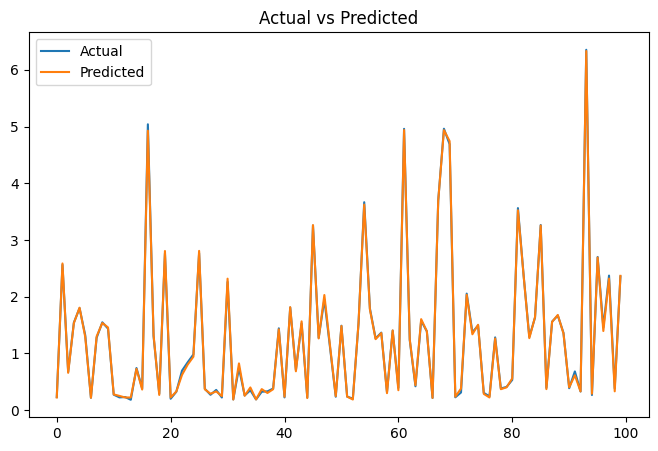

In [34]:
# ======================
# Plot Predictions
# ======================
plt.figure(figsize=(8,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred_rf[:100], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()